In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12_sft-full"

data_dir = Path("data") / "ch12" / "sft-full"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
32,1250,28,train,1.587,0.000089,2025-11-11T06:49:01+08:00
30,1200,27,train,1.637,0.000090,2025-11-11T06:47:04+08:00
29,1150,25,train,1.709,0.000091,2025-11-11T06:45:10+08:00
28,1100,24,train,1.776,0.000092,2025-11-11T06:43:16+08:00
27,1050,23,train,1.836,0.000093,2025-11-11T06:41:22+08:00
25,1000,22,train,1.898,0.000094,2025-11-11T06:39:25+08:00
24,950,21,train,1.972,0.000095,2025-11-11T06:37:31+08:00
23,900,20,train,2.031,0.000095,2025-11-11T06:35:37+08:00
22,850,19,train,2.134,0.000096,2025-11-11T06:33:43+08:00
20,800,18,train,2.206,0.000097,2025-11-11T06:31:46+08:00


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
20,800,18,train,2.206,0.000097,2025-11-11T06:31:46+08:00
22,850,19,train,2.134,0.000096,2025-11-11T06:33:43+08:00
23,900,20,train,2.031,0.000095,2025-11-11T06:35:37+08:00
24,950,21,train,1.972,0.000095,2025-11-11T06:37:31+08:00
25,1000,22,train,1.898,0.000094,2025-11-11T06:39:25+08:00
27,1050,23,train,1.836,0.000093,2025-11-11T06:41:22+08:00
28,1100,24,train,1.776,0.000092,2025-11-11T06:43:16+08:00
29,1150,25,train,1.709,0.000091,2025-11-11T06:45:10+08:00
30,1200,27,train,1.637,0.000090,2025-11-11T06:47:04+08:00
32,1250,28,train,1.587,0.000089,2025-11-11T06:49:01+08:00


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
4,200,5,eval,7.940,NaN,2025-11-11T05:53:15+08:00
9,400,9,eval,8.269,NaN,2025-11-11T06:00:51+08:00
16,600,14,eval,9.381,NaN,2025-11-11T06:24:11+08:00
21,800,18,eval,9.848,NaN,2025-11-11T06:31:48+08:00
26,1000,22,eval,10.263,NaN,2025-11-11T06:39:27+08:00
31,1200,27,eval,10.809,NaN,2025-11-11T06:47:07+08:00


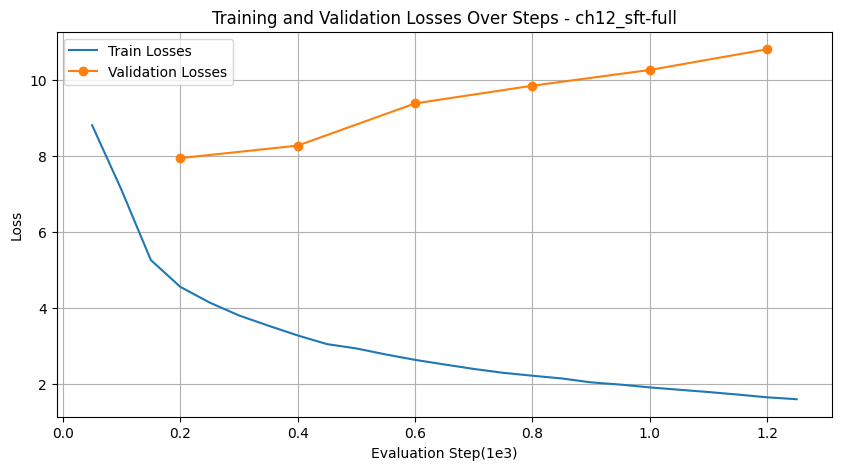

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

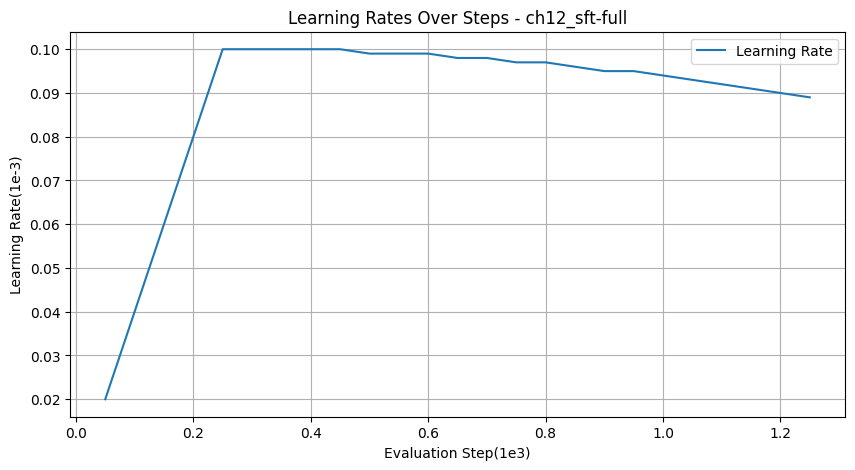

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")